In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(cowplot)
library(immunarch)
library(ggbreak)
library(PNWColors)

Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.2 but the current
version is 1.7.3; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Loading required package: dtplyr

Loading required package: data.table

Warning message:
“package ‘data.table’ was built under R version 4.4.3”

Attaching package: ‘data.table’


The following objects are masked from ‘package:dp

In [2]:
so <- readRDS('../Fig1c_d_e_f_g_Benchmarking/seurat_objects/integrated_so.rds')

In [3]:
df <- so@meta.data %>%
    dplyr::group_by(tech, L2) %>%
    dplyr::summarise(count = n()) %>%
    dplyr::group_by(tech) %>%
    mutate(prop = count / sum(count))
head(df)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by tech and L2.
ℹ Output is grouped by tech.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(tech, L2))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


tech,L2,count,prop
<chr>,<chr>,<int>,<dbl>
10x_5prime,ASDC,5,0.0003065792
10x_5prime,CD14 monocyte,1658,0.1016616592
10x_5prime,CD16 monocyte,273,0.0167392237
10x_5prime,CD56bright NK cell,103,0.0063155313
10x_5prime,CD56dim NK cell,1194,0.0732111104
10x_5prime,CD8aa,46,0.0028205285


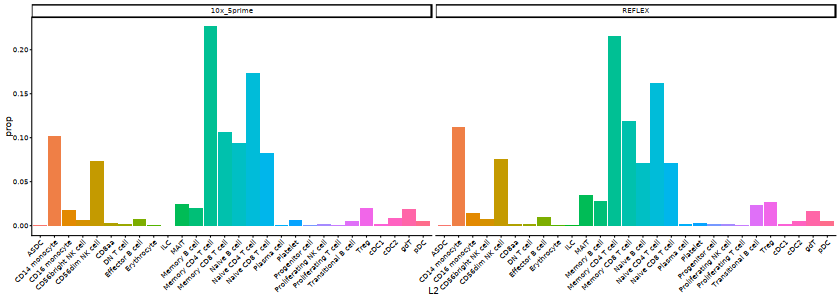

In [4]:
options(repr.plot.width = 7, repr.plot.height = 2.5)
ggplot(df, aes(x=L2, y=prop, fill=L2)) + geom_bar(stat='identity') + 
    theme_classic(base_size = 5) + theme(axis.text.x = element_text(angle=45, hjust=1, vjust=1), legend.position = 'none') + facet_grid(cols = vars(tech))

In [5]:
# Open the PDF graphics device
pdf("plots/Supp3_Cell_Type_Proportions.pdf", width = 7, height = 2.5) # You can specify width and height in inches

# Create your plot
ggplot(df, aes(x=L2, y=prop, fill=L2)) + geom_bar(stat='identity') + 
    theme_classic(base_size = 5) + theme(axis.text.x = element_text(angle=45, hjust=1, vjust=1), legend.position = 'none') + facet_grid(cols = vars(tech))

# Close the graphics device to save the plot
dev.off()

pdf 
  2

In [6]:
reflex_data <- subset(so, tech == 'REFLEX')

In [7]:
reflex_data$orig.ident = factor(reflex_data$orig.ident, levels = c('sample1','sample2','sample3',
                                                      'sample4','sample5','sample6',
                                                      'sample7','sample8','sample9',
                                                      'sample10','sample11','sample12',
                                                      'sample13','sample14','sample15','sample16'))

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“annotation$theme is not a valid theme.
Please use `theme()` to construct themes.”
Warning message:
“annotation$theme is not a valid theme.
Please use `theme()` to construct themes.”


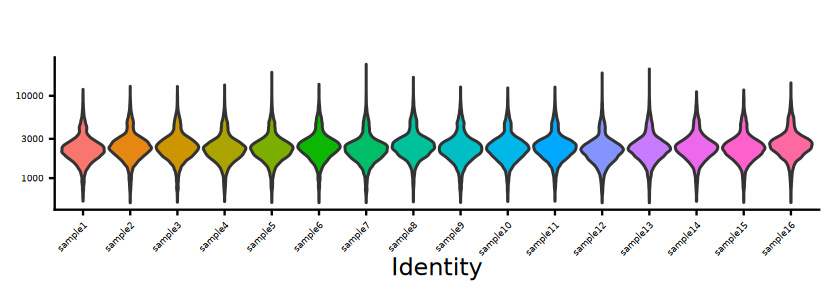

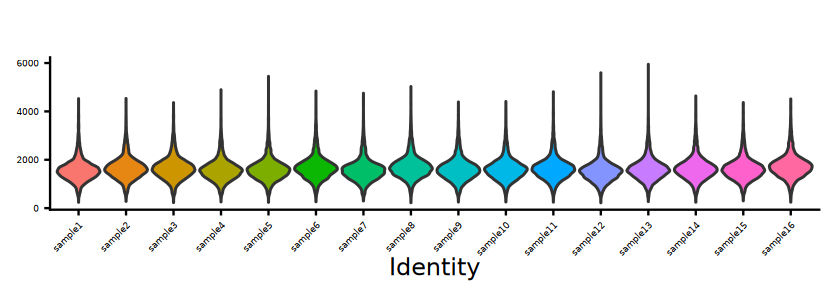

In [8]:
options(repr.plot.width = 7, repr.plot.height = 2.5)
VlnPlot(reflex_data, features = 'nCount_RNA', group.by = 'orig.ident', pt.size = 0, log = T, raster = F) & 
    RotatedAxis() & theme(legend.position = 'none', axis.text = element_text(size = 5)) & ggtitle('')
VlnPlot(reflex_data, features = 'nFeature_RNA', group.by = 'orig.ident', pt.size = 0, log = F, raster = F) & 
    RotatedAxis() & theme(legend.position = 'none', axis.text = element_text(size = 5)) & ggtitle('')

In [13]:
# Open the PDF graphics device
pdf("plots/Supp3_UMIs_violin_plots.pdf", width = 7, height = 2.5) # You can specify width and height in inches

# Create your plot
VlnPlot(reflex_data, features = 'nCount_RNA', group.by = 'orig.ident', pt.size = 0, log = T, raster = F) & 
    RotatedAxis() & theme(legend.position = 'none', axis.text = element_text(size = 5)) & ggtitle('')

# Close the graphics device to save the plot
dev.off()

Warning message:
“annotation$theme is not a valid theme.
Please use `theme()` to construct themes.”


pdf 
  2

In [14]:
# Open the PDF graphics device
pdf("plots/Supp3_genes_violin_plots.pdf", width = 7, height = 2.5) # You can specify width and height in inches

# Create your plot
VlnPlot(reflex_data, features = 'nFeature_RNA', group.by = 'orig.ident', pt.size = 0, log = F, raster = F) & 
    RotatedAxis() & theme(legend.position = 'none', axis.text = element_text(size = 5)) & ggtitle('')

# Close the graphics device to save the plot
dev.off()

Warning message:
“annotation$theme is not a valid theme.
Please use `theme()` to construct themes.”


pdf 
  2

In [10]:
clone_type_df_total <- so@meta.data  %>%
    filter(tech == 'REFLEX') %>%
    filter(L2 %in% c('Naive CD4 T cell','Memory CD4 T cell','Treg','Naive CD8 T cell','Memory CD8 T cell','CD8aa','DN T cell','MAIT','Proliferating T cell')) %>%
    group_by(orig.ident, clone_type) %>%
    summarise(count = n()) %>%
    group_by(orig.ident) %>%
    mutate(prop = count / sum(count)) %>%
    filter(clone_type != 'No clone')
# clone_type_df_total

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by orig.ident and clone_type.
ℹ Output is grouped by orig.ident.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(orig.ident, clone_type))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


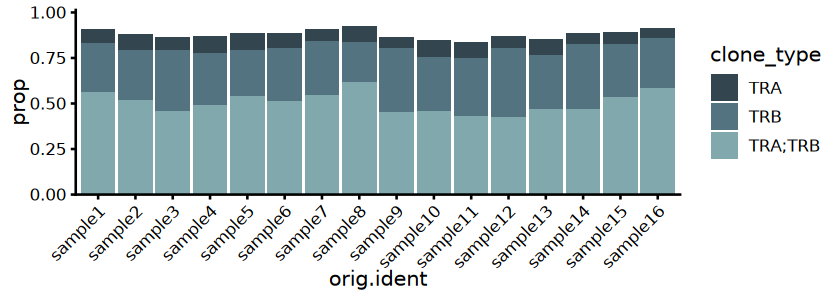

In [11]:
options(repr.plot.width = 7, repr.plot.height = 2.5)
clone_type_df_total %>%
    mutate(clone_type = factor(clone_type, levels = c('TRA','TRB','TRA;TRB'))) %>%
    mutate(orig.ident = factor(orig.ident, levels = c('sample1','sample2','sample3',
                                                      'sample4','sample5','sample6',
                                                      'sample7','sample8','sample9',
                                                      'sample10','sample11','sample12',
                                                      'sample13','sample14','sample15','sample16'))) %>%
    ggplot(aes(x = orig.ident, y = prop, fill = clone_type)) +
      geom_bar(stat = 'identity') +
      theme_classic(base_size = 12) +
      RotatedAxis() + scale_fill_manual(values = c('#33454e','#537380','#81a9ad')) +
      theme(legend.position = 'right') +
      scale_y_continuous(expand = expansion(mult = c(0, 0.1)))

In [15]:
# Open the PDF graphics device
pdf("plots/Supp3_clone_type_barcode_plots_legend.pdf", width = 7, height = 2.5) # You can specify width and height in inches

# Create your plot
clone_type_df_total %>%
    mutate(clone_type = factor(clone_type, levels = c('TRA','TRB','TRA;TRB'))) %>%
    mutate(orig.ident = factor(orig.ident, levels = c('sample1','sample2','sample3',
                                                      'sample4','sample5','sample6',
                                                      'sample7','sample8','sample9',
                                                      'sample10','sample11','sample12',
                                                      'sample13','sample14','sample15','sample16'))) %>%
    ggplot(aes(x = orig.ident, y = prop, fill = clone_type)) +
      geom_bar(stat = 'identity') +
      theme_classic(base_size = 5) +
      RotatedAxis() + scale_fill_manual(values = c('#33454e','#537380','#81a9ad')) +
      theme(legend.position = 'bottom') +
      scale_y_continuous(expand = expansion(mult = c(0, 0.1)))

# Close the graphics device to save the plot
dev.off()

pdf 
  2

In [ ]:
pdf("plots/Supp3_clone_type_barcode_plots_Nolegend.pdf", width = 7, height = 2.5) # You can specify width and height in inches

# Create your plot
clone_type_df_total %>%
    mutate(clone_type = factor(clone_type, levels = c('TRA','TRB','TRA;TRB'))) %>%
    mutate(orig.ident = factor(orig.ident, levels = c('sample1','sample2','sample3',
                                                      'sample4','sample5','sample6',
                                                      'sample7','sample8','sample9',
                                                      'sample10','sample11','sample12',
                                                      'sample13','sample14','sample15','sample16'))) %>%
    ggplot(aes(x = orig.ident, y = prop, fill = clone_type)) +
      geom_bar(stat = 'identity') +
      theme_classic(base_size = 5) +
      RotatedAxis() + scale_fill_manual(values = c('#33454e','#537380','#81a9ad')) +
      theme(legend.position = 'right') +
      scale_y_continuous(expand = expansion(mult = c(0, 0.1)))

# Close the graphics device to save the plot
dev.off()